<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/12_High_Dimensional_Latent_Space_Anomaly_Detection_via_Convolutional_Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision scipy scikit-image matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from skimage.metrics import structural_similarity as ssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

normal_class = 0

normal_images = []

for img,label in train_dataset:
    if label == normal_class:
        normal_images.append((img,label))

train_loader = DataLoader(
    normal_images,
    batch_size=32,
    shuffle=True
)

100%|██████████| 170M/170M [26:22<00:00, 108kB/s] 


In [4]:
class AutoEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(128,64,2,stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64,32,2,stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32,3,2,stride=2),
            nn.Sigmoid()
        )

    def forward(self,x):

        latent = self.encoder(x)

        reconstruction = self.decoder(latent)

        return reconstruction, latent

In [5]:
class SSIMLoss(nn.Module):

    def forward(self,output,target):

        output = output.detach().cpu().numpy()
        target = target.detach().cpu().numpy()

        score = 0

        for i in range(output.shape[0]):

            img1 = np.transpose(output[i],(1,2,0))
            img2 = np.transpose(target[i],(1,2,0))

            score += ssim(
                img1,
                img2,
                channel_axis=2,
                data_range=1.0
            )

        score /= output.shape[0]

        return torch.tensor(
            1-score,
            requires_grad=True
        ).to(device)

In [6]:
model = AutoEncoder().to(device)

criterion = SSIMLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [7]:
epochs = 5

for epoch in range(epochs):

    total_loss = 0

    model.train()

    for images,_ in train_loader:

        images = images.to(device)

        optimizer.zero_grad()

        outputs,_ = model(images)

        loss = criterion(outputs,images)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}"
    )

Epoch 1 Loss: 0.6552
Epoch 2 Loss: 0.6552
Epoch 3 Loss: 0.6551
Epoch 4 Loss: 0.6553
Epoch 5 Loss: 0.6550


In [8]:
test_img,label = train_dataset[100]

x = test_img.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    reconstruction,latent = model(x)

In [9]:
original = test_img.permute(1,2,0).numpy()

reconstructed = reconstruction.squeeze().cpu().permute(1,2,0).numpy()

error = np.abs(original-reconstructed)

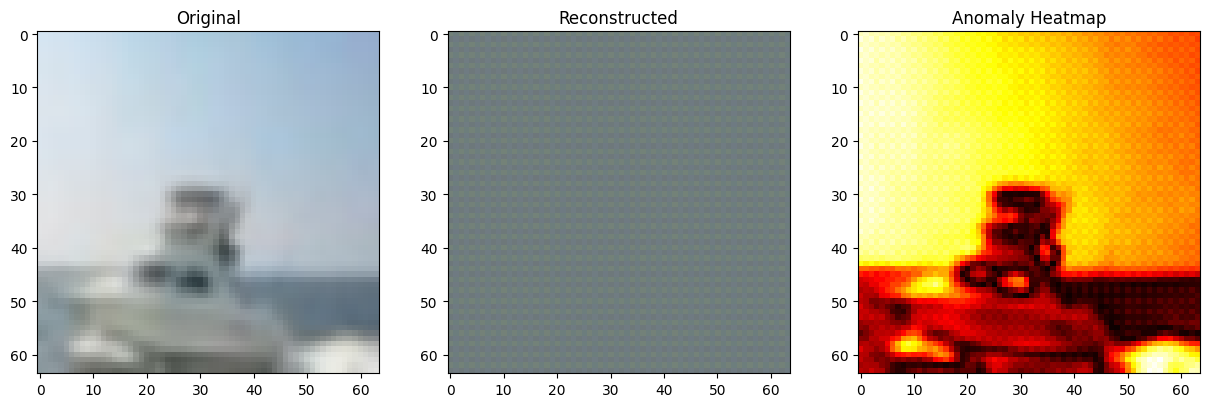

In [10]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(reconstructed)
plt.title("Reconstructed")

plt.subplot(1,3,3)
plt.imshow(error.mean(axis=2),cmap="hot")
plt.title("Anomaly Heatmap")

plt.show()

In [11]:
score = np.mean(error)

print("Anomaly Score :",score)

threshold = 0.08

if score > threshold:
    print("Anomaly Detected")
else:
    print("Normal Image")

Anomaly Score : 0.25061902
Anomaly Detected


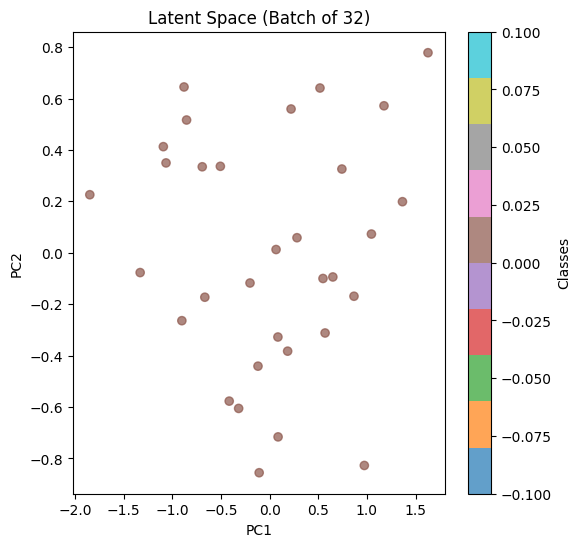

In [16]:
from sklearn.decomposition import PCA
import numpy as np

# 1. Collect latent vectors for a batch of images
model.eval()
latents = []
labels_list = []

with torch.no_grad():
    # Grab one batch from your train_loader (batch_size is 32 based on your setup)
    images, labels = next(iter(train_loader))
    images = images.to(device)

    # Get the latent representations
    _, latent_batch = model(images)

    # Flatten them: (batch_size, channels, H, W) -> (batch_size, features)
    latent_batch = latent_batch.view(latent_batch.size(0), -1).cpu().numpy()

    latents.append(latent_batch)
    labels_list.append(labels.numpy())

# Stack into a single numpy array
latent_data = np.vstack(latents)
label_data = np.concatenate(labels_list)

# 2. Apply PCA (now n_samples is 32, which is > 2)
pca = PCA(n_components=2)
latent2d = pca.fit_transform(latent_data)

# 3. Plot the results
plt.figure(figsize=(6, 6))
# Using c=label_data lets you color-code the points by their class!
scatter = plt.scatter(latent2d[:, 0], latent2d[:, 1], c=label_data, cmap='tab10', alpha=0.7)
plt.title("Latent Space (Batch of 32)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Classes")
plt.show()